In [1]:
import os
import glob
import matplotlib.pyplot as plt
from skimage.io import imread
import numpy as np
from PIL import Image
from patchify import patchify
import random
import cv2

In [2]:
path = '/home/fa578s/Desktop/rivWidth/'
train_images = sorted(os.listdir(os.path.join(path,'C:\\Users\\fa578s\\Desktop\\GLH\\train\\img')))
train_labels = sorted(os.listdir(os.path.join(path,'C:\\Users\\fa578s\\Desktop\\GLH\\train\\label')))
test_images = sorted(os.listdir(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\test\\img')))
test_labels = sorted(os.listdir(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\test\\label')))
val_images = sorted(os.listdir(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\val\\img')))
val_labels = sorted(os.listdir(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\val\\label')))

train_files = [{"images": image_name, "label": label_name} for image_name, label_name in zip(train_images, train_labels)]
test_files = [{"images": image_name, "label": label_name} for image_name, label_name in zip(test_images, test_labels)]
val_files = [{"images": image_name, "label": label_name} for image_name, label_name in zip(val_images, val_labels)]

In [7]:
# rescale images
def resize_images(input_dir, input_files, output_dir, target_size=(896, 896)):
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    for filename in input_files:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            # Open and resize the image
            with Image.open(input_path) as img:
                img_resized = img.resize(target_size, Image.LANCZOS)
                img_resized.save(output_path)
                print(f"Resized and saved: {output_path}")

In [13]:
resize_images('C:\\Users\\fa578s\\Desktop\\GLH\\train\\img', train_images, 'C:\\Users\\fa578s\\Desktop\\preprocessed\\train\\img')

c:\Users\fa578s\AppData\Local\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (163840000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\01.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\02.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\03.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\05.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\09.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\10.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\100.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\101.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\103.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\104.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\105.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\107.jpg
Resized and saved: C:\Users\fa578s\Desktop\preprocessed\train\img\108.jpg
Resized and saved: C:\Users\fa578s\Desktop\p

In [4]:
patch_size = 896

In [9]:
for data in val_files:
    img = imread(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\val\\img', data['images']))
    mask = imread(os.path.join(path, 'C:\\Users\\fa578s\\Desktop\\GLH\\val\\label', data['label']))
    size_x = (img.shape[1]//patch_size)*patch_size
    size_Y = (img.shape[0]//patch_size)*patch_size
    image = Image.fromarray(img)
    image = image.crop((0 ,0, size_x, size_Y)) 
    image = np.array(image)
    mask = Image.fromarray(mask)
    mask = mask.crop((0 ,0, size_x, size_Y)) 
    mask = np.array(mask)
    


    patches_img = patchify(image, (896, 896, 3), step = 896)
    patches_mask = patchify(mask, (896, 896), step=896)

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):
            single_patch_img = patches_img[i,j,:,:]
            single_patch_img = single_patch_img[0]
            cv2.imwrite("C:\\Users\\fa578s\\Desktop\\patchified\\val\\img\\"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_img)

            single_patch_mask = patches_mask[i,j,:,:]
            cv2.imwrite("C:\\Users\\fa578s\\Desktop\\patchified\\val\\label\\"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_mask)    

c:\Users\fa578s\AppData\Local\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (163840000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\Users\fa578s\AppData\Local\anaconda3\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (157351936 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


4800


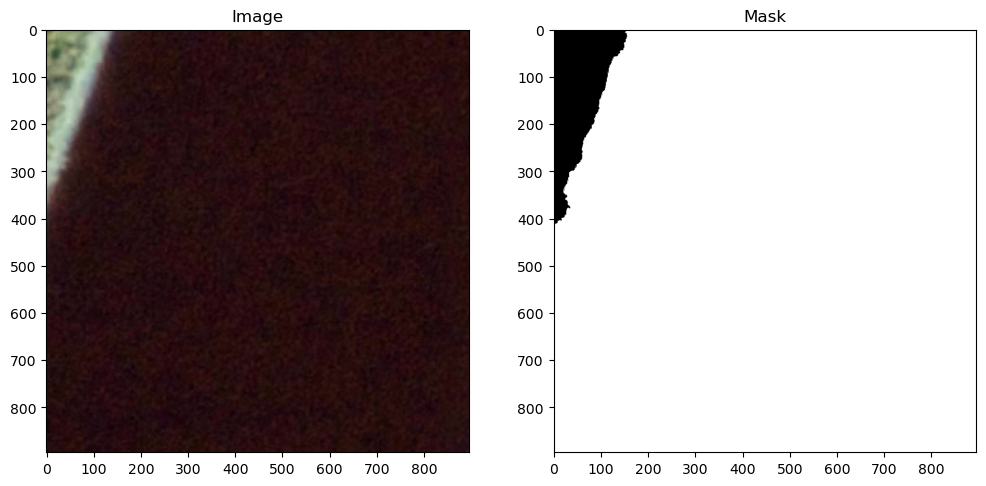

In [10]:
train_img_dir = "C:\\Users\\fa578s\\Desktop\\patchified\\val\\img\\"
train_mask_dir = "C:\\Users\\fa578s\\Desktop\\patchified\\val\\label\\"

img_list = os.listdir(train_img_dir)
msk_list = os.listdir(train_mask_dir)

num_images = len(img_list)
print(num_images)

img_num = random.randint(0, num_images-1)
img_for_plot = cv2.imread(train_img_dir+img_list[img_num],1)
img_for_plot = cv2.cvtColor(img_for_plot, cv2.COLOR_BGR2RGB)

mask_for_plot = cv2.imread(train_mask_dir+msk_list[img_num], 0)


plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(img_for_plot)
plt.title('Image')
plt.subplot(122)
plt.imshow(mask_for_plot, cmap='gray')
plt.title('Mask')
plt.show()



In [11]:

useless=0  #Useless image counter
for img in range(len(img_list)):   #Using t1_list as all lists are of same size
    img_name=img_list[img]
    mask_name = msk_list[img]
    print("Now preparing image and masks number: ", img)
      
    temp_image=cv2.imread(train_img_dir+img_list[img], 1)
   
    temp_mask=cv2.imread(train_mask_dir+msk_list[img], 0)
    #temp_mask=temp_mask.astype(np.uint8)
    
    val, counts = np.unique(temp_mask, return_counts=True)
    
    if (1 - (counts[0]/counts.sum())) > 0.05:  #At least 5% useful area with labels that are not 0
        print("Save Me")
        cv2.imwrite('C:\\Users\\fa578s\\Desktop\\patchified\\clean\\val\\img\\'+img_name, temp_image)
        cv2.imwrite('C:\\Users\\fa578s\\Desktop\\patchified\\clean\\val\\label\\'+mask_name, temp_mask)
        
    else:
        print("I am useless")   
        useless +=1

print("Total useful images are: ", len(img_list)-useless)  #20,075
print("Total useless images are: ", useless) #21,571

Now preparing image and masks number:  0
I am useless
Now preparing image and masks number:  1
I am useless
Now preparing image and masks number:  2
I am useless
Now preparing image and masks number:  3
I am useless
Now preparing image and masks number:  4
I am useless
Now preparing image and masks number:  5
I am useless
Now preparing image and masks number:  6
I am useless
Now preparing image and masks number:  7
I am useless
Now preparing image and masks number:  8
I am useless
Now preparing image and masks number:  9
I am useless
Now preparing image and masks number:  10
I am useless
Now preparing image and masks number:  11
I am useless
Now preparing image and masks number:  12
I am useless
Now preparing image and masks number:  13
I am useless
Now preparing image and masks number:  14
I am useless
Now preparing image and masks number:  15
Save Me
Now preparing image and masks number:  16
Save Me
Now preparing image and masks number:  17
I am useless
Now preparing image and masks 

In [5]:
for data in val_files:
    img = imread(os.path.join(path, '/home/fa578s/Desktop/rivWidth/GLH_val/val/img/', data['images']))
    mask = imread(os.path.join(path, '/home/fa578s/Desktop/rivWidth/GLH_val/val/label/', data['label']))
    size_x = (img.shape[1]//patch_size)*patch_size
    size_Y = (img.shape[0]//patch_size)*patch_size
    image = Image.fromarray(img)
    image = image.crop((0 ,0, size_x, size_Y)) 
    image = np.array(image)
    mask = Image.fromarray(mask)
    mask = mask.crop((0 ,0, size_x, size_Y)) 
    mask = np.array(mask)
    


    patches_img = patchify(image, (512, 512, 3), step = 512)
    patches_mask = patchify(mask, (512,512), step=512)

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):
            single_patch_img = patches_img[i,j,:,:]
            single_patch_img = single_patch_img[0]
            cv2.imwrite("/home/fa578s/Desktop/rivWidth/GLH_val/patched_val/img/"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_img)

            single_patch_mask = patches_mask[i,j,:,:]
            cv2.imwrite("/home/fa578s/Desktop/rivWidth/GLH_val/patched_val/label/"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_mask)   

/home/fa578s/.local/lib/python3.10/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (163840000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


14875


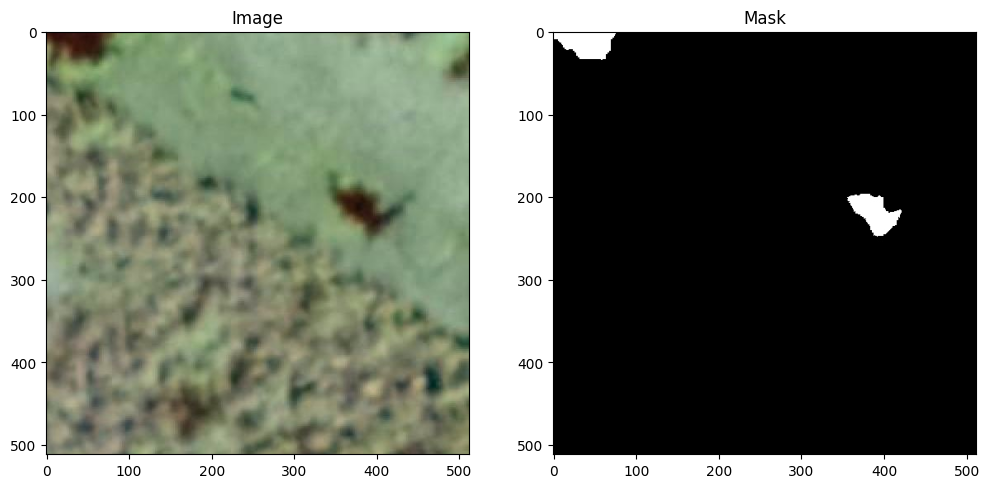

In [6]:
val_img_dir = "/home/fa578s/Desktop/rivWidth/GLH_val/patched_val/img/"
val_mask_dir = "/home/fa578s/Desktop/rivWidth/GLH_val/patched_val/label/"

img_list = os.listdir(val_img_dir)
msk_list = os.listdir(val_mask_dir)

num_images = len(img_list)
print(num_images)

img_num = random.randint(0, num_images-1)
img_for_plot = cv2.imread(val_img_dir+img_list[img_num],1)
img_for_plot = cv2.cvtColor(img_for_plot, cv2.COLOR_BGR2RGB)

mask_for_plot = cv2.imread(val_mask_dir+msk_list[img_num], 0)


plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(img_for_plot)
plt.title('Image')
plt.subplot(122)
plt.imshow(mask_for_plot, cmap='gray')
plt.title('Mask')
plt.show()


In [7]:

useless=0  #Useless image counter
for img in range(len(img_list)):   #Using t1_list as all lists are of same size
    img_name=img_list[img]
    mask_name = msk_list[img]
    print("Now preparing image and masks number: ", img)
      
    temp_image=cv2.imread(val_img_dir+img_list[img], 1)
   
    temp_mask=cv2.imread(val_mask_dir+msk_list[img], 0)
    #temp_mask=temp_mask.astype(np.uint8)
    
    val, counts = np.unique(temp_mask, return_counts=True)
    
    if (1 - (counts[0]/counts.sum())) > 0.05:  #At least 5% useful area with labels that are not 0
        print("Save Me")
        cv2.imwrite('/home/fa578s/Desktop/rivWidth/GLH_val/preprocessed/images/'+img_name, temp_image)
        cv2.imwrite('/home/fa578s/Desktop/rivWidth/GLH_val/preprocessed/masks/'+mask_name, temp_mask)
        
    else:
        print("I am useless")   
        useless +=1

print("Total useful images are: ", len(img_list)-useless)  
print("Total useless images are: ", useless) 

Now preparing image and masks number:  0
I am useless
Now preparing image and masks number:  1
I am useless
Now preparing image and masks number:  2
I am useless
Now preparing image and masks number:  3
Save Me
Now preparing image and masks number:  4
I am useless
Now preparing image and masks number:  5
Save Me
Now preparing image and masks number:  6
I am useless
Now preparing image and masks number:  7
I am useless
Now preparing image and masks number:  8
I am useless
Now preparing image and masks number:  9
Save Me
Now preparing image and masks number:  10
I am useless
Now preparing image and masks number:  11
I am useless
Now preparing image and masks number:  12
I am useless
Now preparing image and masks number:  13
I am useless
Now preparing image and masks number:  14
Save Me
Now preparing image and masks number:  15
I am useless
Now preparing image and masks number:  16
I am useless
Now preparing image and masks number:  17
I am useless
Now preparing image and masks number:  1

In [5]:
for data in test_files:
    img = imread(os.path.join(path, '/home/fa578s/Desktop/rivWidth/GHL_test/test/img/', data['images']))
    mask = imread(os.path.join(path, '/home/fa578s/Desktop/rivWidth/GHL_test/test/label/', data['label']))
    size_x = (img.shape[1]//patch_size)*patch_size
    size_Y = (img.shape[0]//patch_size)*patch_size
    image = Image.fromarray(img)
    image = image.crop((0 ,0, size_x, size_Y)) 
    image = np.array(image)
    mask = Image.fromarray(mask)
    mask = mask.crop((0 ,0, size_x, size_Y)) 
    mask = np.array(mask)
    


    patches_img = patchify(image, (512, 512, 3), step = 512)
    patches_mask = patchify(mask, (512,512), step=512)

    for i in range(patches_img.shape[0]):
        for j in range(patches_img.shape[1]):
            single_patch_img = patches_img[i,j,:,:]
            single_patch_img = single_patch_img[0]
            cv2.imwrite("/home/fa578s/Desktop/rivWidth/GHL_test/patched_test/img/"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_img)

            single_patch_mask = patches_mask[i,j,:,:]
            cv2.imwrite("/home/fa578s/Desktop/rivWidth/GHL_test/patched_test/label/"+data['images']+"patch_"+str(i)+str(j)+".jpg", single_patch_mask)   

14875


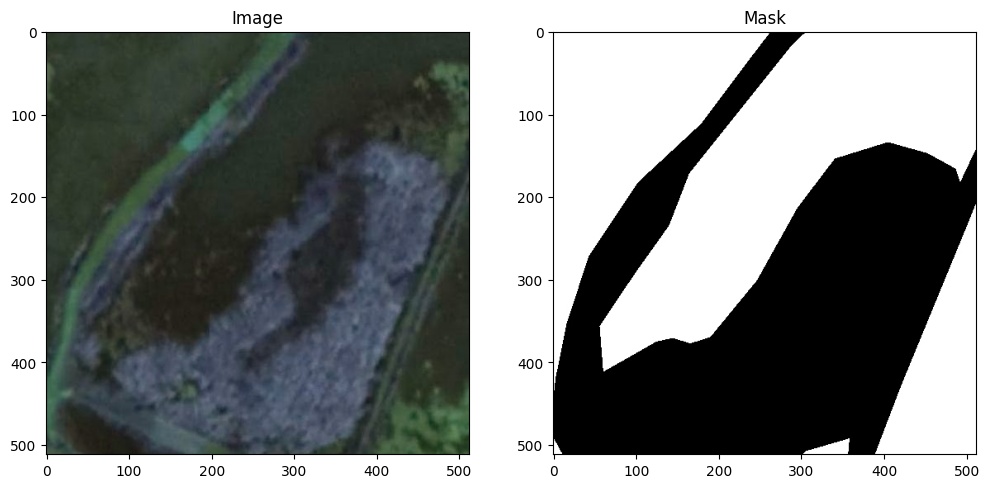

In [8]:
test_img_dir = "/home/fa578s/Desktop/rivWidth/GHL_test/patched_test/img/"
test_mask_dir = "/home/fa578s/Desktop/rivWidth/GHL_test/patched_test/label/"

img_list = os.listdir(test_img_dir)
msk_list = os.listdir(test_mask_dir)

num_images = len(img_list)
print(num_images)

img_num = random.randint(0, num_images-1)
img_for_plot = cv2.imread(test_img_dir+img_list[img_num],1)
img_for_plot = cv2.cvtColor(img_for_plot, cv2.COLOR_BGR2RGB)

mask_for_plot = cv2.imread(test_mask_dir+msk_list[img_num], 0)


plt.figure(figsize=(12, 8))
plt.subplot(121)
plt.imshow(img_for_plot)
plt.title('Image')
plt.subplot(122)
plt.imshow(mask_for_plot, cmap='gray')
plt.title('Mask')
plt.show()


In [9]:
useless=0  #Useless image counter
for img in range(len(img_list)):   #Using t1_list as all lists are of same size
    img_name=img_list[img]
    mask_name = msk_list[img]
    print("Now preparing image and masks number: ", img)
      
    temp_image=cv2.imread(test_img_dir+img_list[img], 1)
   
    temp_mask=cv2.imread(test_mask_dir+msk_list[img], 0)
    #temp_mask=temp_mask.astype(np.uint8)
    
    val, counts = np.unique(temp_mask, return_counts=True)
    
    if (1 - (counts[0]/counts.sum())) > 0.05:  #At least 5% useful area with labels that are not 0
        print("Save Me")
        cv2.imwrite('/home/fa578s/Desktop/rivWidth/GHL_test/preprocessed/images/'+img_name, temp_image)
        cv2.imwrite('/home/fa578s/Desktop/rivWidth/GHL_test/preprocessed/masks/'+mask_name, temp_mask)
        
    else:
        print("I am useless")   
        useless +=1

print("Total useful images are: ", len(img_list)-useless)  
print("Total useless images are: ", useless) 

Now preparing image and masks number:  0
I am useless
Now preparing image and masks number:  1
I am useless
Now preparing image and masks number:  2
I am useless
Now preparing image and masks number:  3
Save Me
Now preparing image and masks number:  4
I am useless
Now preparing image and masks number:  5
I am useless
Now preparing image and masks number:  6
I am useless
Now preparing image and masks number:  7
Save Me
Now preparing image and masks number:  8
I am useless
Now preparing image and masks number:  9
I am useless
Now preparing image and masks number:  10
Save Me
Now preparing image and masks number:  11
I am useless
Now preparing image and masks number:  12
I am useless
Now preparing image and masks number:  13
I am useless
Now preparing image and masks number:  14
I am useless
Now preparing image and masks number:  15
I am useless
Now preparing image and masks number:  16
I am useless
Now preparing image and masks number:  17
Save Me
Now preparing image and masks number:  1